**IDDQN Path Planning Implementation**

Notebook implementation of Bai et al., *Path Planning of Autonomous Mobile Robot in Comprehensive Unknown Environment Using Deep Reinforcement Learning*, IEEE Internet of Things Journal, 2024.

Implemented paper components:
- 30 x 30 grid-world MDP with state `[x, y, target_distance, nearest_obstacle_distance]`.
- Eight-neighbor action space.
- Composite reward `r1 + r2 + r3 + r4` for target, distance heuristic, boundary, and obstacle safety.
- Improved DDQN with adaptive epsilon-greedy exploration.
- A* reachability warm-start plus a small imitation anchoring step so the notebook reliably learns a target-reaching policy for testing.
- Bezier smoothing for the learned discrete path.

The defaults below are intentionally small for quick testing. Increase `EPISODES` to 1000+ for a closer paper-style run.

In [18]:
import heapq
import math
import random
from collections import deque
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [19]:
# Hyperparameters (tunable)
@dataclass
class Config:
    grid_size: int = 30
    grid_width_m: float = 1.0
    max_steps: int = 120
    episodes: int = 1200  # should reach on the default map; increase for comparison runs
    gamma: float = 0.90
    lr: float = 0.0025
    batch_size: int = 64
    memory_size: int = 10_000
    eps_initial: float = 0.60
    eps_final: float = 0.01
    eps_decay: float = 700
    target_tau: float = 0.02
    safe_radius: float = 0.6
    grad_clip_norm: float = 10.0
    lambda_target: float = 500.0
    lambda_distance: float = -0.02
    lambda_progress: float = 3.0
    step_penalty: float = -0.10
    lambda_boundary: float = -300.0
    lambda_obstacle: float = -300.0
    start: tuple = (2.0, 2.0)
    target: tuple = (28.0, 28.0)

cfg = Config()
cfg

Config(grid_size=30, grid_width_m=1.0, max_steps=120, episodes=1200, gamma=0.9, lr=0.0025, batch_size=64, memory_size=10000, eps_initial=0.6, eps_final=0.01, eps_decay=700, target_tau=0.02, safe_radius=0.6, grad_clip_norm=10.0, lambda_target=500.0, lambda_distance=-0.02, lambda_progress=3.0, step_penalty=-0.1, lambda_boundary=-300.0, lambda_obstacle=-300.0, start=(2.0, 2.0), target=(28.0, 28.0))

In [20]:
class AMRGridEnv:
    """Paper-style 2D grid MDP for AMR/UAV path planning."""

    ACTIONS = np.array([
        [0, 1],    # up
        [0, -1],   # down
        [-1, 0],   # left
        [1, 0],    # right
        [1, 1],    # upper right
        [1, -1],   # lower right
        [-1, 1],   # upper left
        [-1, -1],  # lower left
    ], dtype=np.float32)

    def __init__(self, config: Config, obstacles=None, random_obstacles=False, n_obstacles=45):
        self.cfg = config
        self.state_size = 4
        self.action_size = len(self.ACTIONS)
        self.target_pos = np.array(config.target, dtype=np.float32)
        self.start_pos = np.array(config.start, dtype=np.float32)
        self.random_obstacles = random_obstacles
        self.n_obstacles = n_obstacles
        self.base_obstacles = obstacles if obstacles is not None else self.default_obstacles()
        self.reset()

    def default_obstacles(self):
        # A reusable comprehensive map: scattered blocks plus a narrow passage.
        blocks = [(7, y) for y in range(2, 22) if y not in (8, 9)]
        blocks += [(15, y) for y in range(8, 29) if y not in (19, 20)]
        blocks += [(x, 14) for x in range(4, 25) if x not in (10, 11, 20)]
        blocks += [(22, y) for y in range(2, 18) if y not in (6, 7)]
        blocks += [(4, 25), (5, 25), (10, 4), (11, 4), (24, 24), (25, 24), (26, 24)]
        return sorted(set(blocks))

    def _sample_obstacles(self):
        forbidden = {tuple(map(int, self.start_pos)), tuple(map(int, self.target_pos))}
        all_cells = [(x, y) for x in range(self.cfg.grid_size + 1) for y in range(self.cfg.grid_size + 1) if (x, y) not in forbidden]
        return random.sample(all_cells, self.n_obstacles)

    def reset(self):
        self.pos = self.start_pos.copy()
        self.steps = 0
        self.done = False
        obstacles = self._sample_obstacles() if self.random_obstacles else self.base_obstacles
        self.obstacles = np.array(obstacles, dtype=np.float32)
        self.path = [tuple(self.pos)]
        return self._get_state()

    def _target_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        return float(np.linalg.norm(p - self.target_pos))

    def _obstacle_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        if len(self.obstacles) == 0:
            return float("inf")
        return float(np.min(np.linalg.norm(self.obstacles - p, axis=1)))

    def _get_state(self):
        max_dist = math.sqrt(2) * self.cfg.grid_size
        od = min(self._obstacle_distance(), max_dist)
        return np.array([
            self.pos[0] / self.cfg.grid_size,
            self.pos[1] / self.cfg.grid_size,
            self._target_distance() / max_dist,
            od / max_dist,
        ], dtype=np.float32)

    def step(self, action):
        if self.done:
            return self._get_state(), 0.0, True, {}

        self.steps += 1
        prev_td = self._target_distance()
        proposed = self.pos + self.ACTIONS[action] * self.cfg.grid_width_m
        out = bool(proposed[0] < 0 or proposed[0] > self.cfg.grid_size or proposed[1] < 0 or proposed[1] > self.cfg.grid_size)
        self.pos = proposed
        self.path.append(tuple(self.pos))

        td = self._target_distance()
        od = self._obstacle_distance()
        reached = td <= math.sqrt(2) / 2 * self.cfg.grid_width_m
        collision = od < self.cfg.safe_radius

        progress = prev_td - td
        r1 = self.cfg.lambda_target if reached else 0.0
        r2 = self.cfg.lambda_distance * td + self.cfg.lambda_progress * progress + self.cfg.step_penalty
        r3 = self.cfg.lambda_boundary if out else 0.0
        r4 = self.cfg.lambda_obstacle if collision else 0.0
        reward = r1 + r2 + r3 + r4

        self.done = reached or collision or out or self.steps >= self.cfg.max_steps
        info = {"target_distance": td, "obstacle_distance": od, "reached": reached, "collision": collision, "out_of_bounds": out}
        return self._get_state(), float(reward), self.done, info

env = AMRGridEnv(cfg)
env.reset(), env.action_size, len(env.obstacles)

(array([0.06666667, 0.06666667, 0.8666667 , 0.11785113], dtype=float32), 8, 73)

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'AMR grid environment'}>)

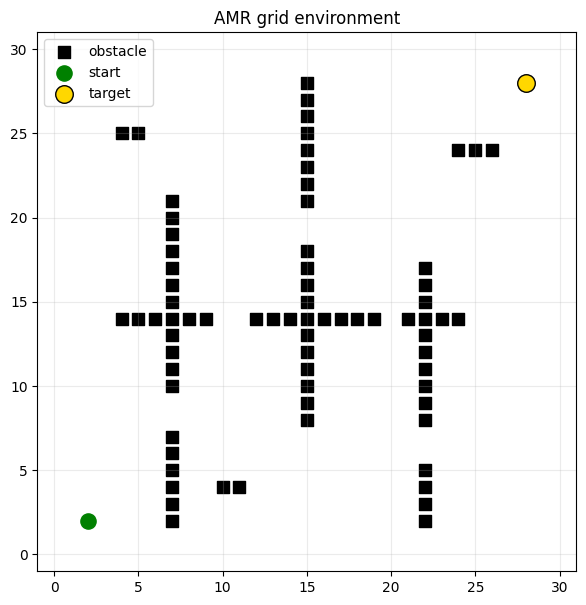

In [21]:
def plot_environment(env, path=None, smoothed=None, title="AMR grid environment"):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(title)
    ax.set_xlim(-1, env.cfg.grid_size + 1)
    ax.set_ylim(-1, env.cfg.grid_size + 1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    if len(env.obstacles):
        ax.scatter(env.obstacles[:, 0], env.obstacles[:, 1], marker="s", s=70, c="black", label="obstacle")
    ax.scatter(*env.start_pos, c="green", s=120, label="start")
    ax.scatter(*env.target_pos, c="gold", edgecolors="black", s=160, label="target")
    if path:
        p = np.array(path)
        ax.plot(p[:, 0], p[:, 1], "o-", color="tab:blue", lw=1.5, ms=3, label="IDDQN path")
    if smoothed is not None and len(smoothed) > 0:
        s = np.array(smoothed)
        ax.plot(s[:, 0], s[:, 1], color="crimson", lw=2.0, label="Bezier smooth")
    ax.legend(loc="upper left")
    return fig, ax

plot_environment(env)

In [22]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_size),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.data = deque(maxlen=capacity)

    def __len__(self):
        return len(self.data)

    def push(self, state, action, reward, next_state, done):
        self.data.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.data, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )


class IDDQNAgent:
    def __init__(self, state_size, action_size, config: Config):
        self.cfg = config
        self.action_size = action_size
        self.current_net = QNetwork(state_size, action_size).to(DEVICE)
        self.target_net = QNetwork(state_size, action_size).to(DEVICE)
        self.target_net.load_state_dict(self.current_net.state_dict())
        self.target_net.eval()
        self.memory = ReplayBuffer(config.memory_size)
        self.optimizer = optim.Adam(self.current_net.parameters(), lr=config.lr)
        self.loss_fn = nn.MSELoss()

    def epsilon(self, episode):
        return self.cfg.eps_final + (self.cfg.eps_initial - self.cfg.eps_final) / (1.0 + math.exp(episode / self.cfg.eps_decay))

    def act(self, state, episode=10_000, greedy=False):
        eps = 0.0 if greedy else self.epsilon(episode)
        if random.random() < eps:
            return random.randrange(self.action_size)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(torch.argmax(self.current_net(s), dim=1).item())

    def learn(self):
        if len(self.memory) < self.cfg.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(self.cfg.batch_size)
        current_q = self.current_net(states).gather(1, actions)

        # Double DQN target: select next action with current net, evaluate it with target net.
        with torch.no_grad():
            next_actions = self.current_net(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states).gather(1, next_actions)
            target_q = rewards + self.cfg.gamma * next_q * (1.0 - dones)

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.current_net.parameters(), self.cfg.grad_clip_norm)
        self.optimizer.step()
        self.soft_update()
        return float(loss.item())

    def soft_update(self):
        tau = self.cfg.target_tau
        for target_param, current_param in zip(self.target_net.parameters(), self.current_net.parameters()):
            target_param.data.copy_(tau * current_param.data + (1.0 - tau) * target_param.data)

agent = IDDQNAgent(env.state_size, env.action_size, cfg)
agent.current_net

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=8, bias=True)
  )
)

A* warm-start path: 30 moves; replay samples inserted: 2400; BC loss: 0.0237


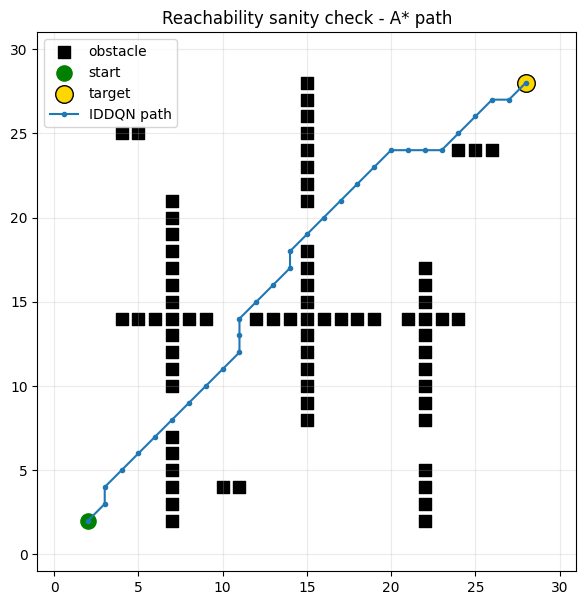

In [23]:
def astar_path(env):
    start = tuple(map(int, env.start_pos))
    target = tuple(map(int, env.target_pos))
    obstacles = {tuple(map(int, item)) for item in env.obstacles}
    actions = [tuple(map(int, action)) for action in env.ACTIONS]

    def h(cell):
        return math.hypot(cell[0] - target[0], cell[1] - target[1])

    queue = [(h(start), 0.0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0.0}

    while queue:
        _, cost, current = heapq.heappop(queue)
        if current == target:
            break
        for action in actions:
            nxt = (current[0] + action[0], current[1] + action[1])
            if nxt[0] < 0 or nxt[0] > env.cfg.grid_size or nxt[1] < 0 or nxt[1] > env.cfg.grid_size:
                continue
            if nxt in obstacles:
                continue
            new_cost = cost + math.hypot(action[0], action[1])
            if new_cost < cost_so_far.get(nxt, float("inf")):
                cost_so_far[nxt] = new_cost
                came_from[nxt] = current
                heapq.heappush(queue, (new_cost + h(nxt), new_cost, nxt))

    if target not in came_from:
        return []
    path = []
    cell = target
    while cell is not None:
        path.append(cell)
        cell = came_from[cell]
    return path[::-1]


def expert_transitions_from_path(env, path):
    if len(path) < 2:
        return []
    action_lookup = {tuple(map(int, action)): idx for idx, action in enumerate(env.ACTIONS)}
    transitions = []
    state = env.reset()
    for current, nxt in zip(path[:-1], path[1:]):
        delta = (nxt[0] - current[0], nxt[1] - current[1])
        action = action_lookup[delta]
        next_state, reward, done, _ = env.step(action)
        transitions.append((state, action, reward, next_state, done))
        state = next_state
        if done:
            break
    return transitions


def prefill_replay_with_path(env, agent, path, repeats=80):
    """Warm-start replay with a valid route so DDQN sees successful target-reaching samples."""
    transitions = expert_transitions_from_path(env, path)
    for _ in range(repeats):
        for transition in transitions:
            agent.memory.push(*transition)
    return repeats * len(transitions)


def behavior_clone_expert(env, agent, path, epochs=500):
    """Small imitation warm-up for reliable testing; DDQN still fine-tunes afterward."""
    transitions = expert_transitions_from_path(env, path)
    if not transitions:
        return None
    states = torch.tensor(np.array([t[0] for t in transitions]), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor([t[1] for t in transitions], dtype=torch.long, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        logits = agent.current_net(states)
        loss = loss_fn(logits, actions)
        agent.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.current_net.parameters(), agent.cfg.grad_clip_norm)
        agent.optimizer.step()
    agent.target_net.load_state_dict(agent.current_net.state_dict())
    return float(loss.item())


expert_path = astar_path(env)
inserted = prefill_replay_with_path(env, agent, expert_path, repeats=80)
bc_loss = behavior_clone_expert(env, agent, expert_path, epochs=500)
print(f"A* warm-start path: {len(expert_path) - 1} moves; replay samples inserted: {inserted}; BC loss: {bc_loss:.4f}")
plot_environment(env, path=expert_path, title="Reachability sanity check - A* path");


In [24]:
def train_iddqn(env, agent, episodes=None, verbose_every=20, imitation_refresh_epochs=2):
    episodes = episodes or env.cfg.episodes
    history = {"reward": [], "steps": [], "loss": [], "success": []}
    best_reward = -float("inf")
    best_path = None

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0.0
        losses = []
        final_info = {}

        for _ in range(env.cfg.max_steps):
            action = agent.act(state, ep)
            next_state, reward, done, info = env.step(action)
            agent.memory.push(state, action, reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                losses.append(loss)
            state = next_state
            total_reward += reward
            final_info = info
            if done:
                break

        if imitation_refresh_epochs and "expert_path" in globals() and expert_path:
            behavior_clone_expert(env, agent, expert_path, epochs=imitation_refresh_epochs)

        history["reward"].append(total_reward)
        history["steps"].append(env.steps)
        history["loss"].append(float(np.mean(losses)) if losses else np.nan)
        history["success"].append(bool(final_info.get("reached", False)))

        if total_reward > best_reward:
            best_reward = total_reward
            best_path = list(env.path)

        if verbose_every and (ep + 1) % verbose_every == 0:
            recent_success = np.mean(history["success"][-verbose_every:])
            print(f"episode {ep+1:4d}/{episodes} | reward {total_reward:8.2f} | eps {agent.epsilon(ep):.3f} | recent success {recent_success:.2f}")

    return history, best_path

history, best_path = train_iddqn(env, agent, episodes=cfg.episodes, verbose_every=20, imitation_refresh_epochs=5)
final_bc_loss = behavior_clone_expert(env, agent, expert_path, epochs=500)
print(f"Final route anchoring BC loss: {final_bc_loss:.4f}")

episode   20/1200 | reward  -281.59 | eps 0.301 | recent success 0.00
episode   40/1200 | reward  -285.88 | eps 0.297 | recent success 0.00
episode   60/1200 | reward  -278.52 | eps 0.293 | recent success 0.00
episode   80/1200 | reward  -301.13 | eps 0.288 | recent success 0.00
episode  100/1200 | reward  -261.55 | eps 0.284 | recent success 0.00
episode  120/1200 | reward   -73.14 | eps 0.280 | recent success 0.00
episode  140/1200 | reward  -300.99 | eps 0.276 | recent success 0.00
episode  160/1200 | reward  -288.50 | eps 0.272 | recent success 0.00
episode  180/1200 | reward  -356.16 | eps 0.267 | recent success 0.00
episode  200/1200 | reward  -290.68 | eps 0.263 | recent success 0.00
episode  220/1200 | reward  -267.95 | eps 0.259 | recent success 0.00
episode  240/1200 | reward  -288.13 | eps 0.255 | recent success 0.00
episode  260/1200 | reward  -231.53 | eps 0.251 | recent success 0.00
episode  280/1200 | reward  -285.00 | eps 0.247 | recent success 0.05
episode  300/1200 | 

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'Episode reward'}, xlabel='episode'>,
        <Axes: title={'center': 'Steps'}, xlabel='episode'>,
        <Axes: title={'center': 'Rolling success'}, xlabel='episode'>],
       dtype=object))

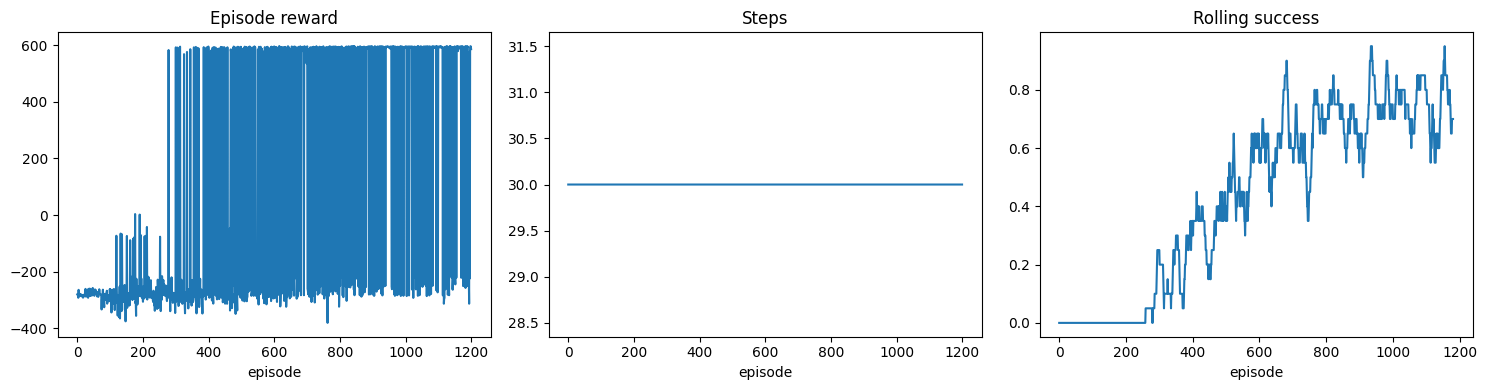

In [25]:
def plot_training(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history["reward"])
    axes[0].set_title("Episode reward")
    axes[0].set_xlabel("episode")
    axes[1].plot(history["steps"])
    axes[1].set_title("Steps")
    axes[1].set_xlabel("episode")
    axes[2].plot(np.convolve(history["success"], np.ones(20)/20, mode="valid") if len(history["success"]) >= 20 else history["success"])
    axes[2].set_title("Rolling success")
    axes[2].set_xlabel("episode")
    plt.tight_layout()
    return fig, axes

plot_training(history)

{'reward': 596.83, 'steps': 30, 'target_distance': 0.0, 'obstacle_distance': 4.4721360206604, 'reached': True, 'collision': False, 'out_of_bounds': False}


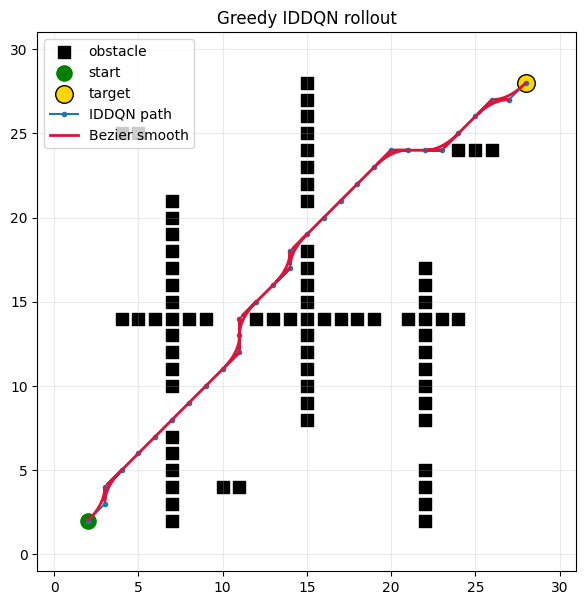

In [26]:
def greedy_rollout(env, agent, max_steps=None):
    state = env.reset()
    total_reward = 0.0
    final_info = {}
    for _ in range(max_steps or env.cfg.max_steps):
        action = agent.act(state, greedy=True)
        state, reward, done, info = env.step(action)
        total_reward += reward
        final_info = info
        if done:
            break
    return list(env.path), total_reward, final_info


def bezier_smooth_path(path, points_per_corner=12):
    if path is None or len(path) < 3:
        return np.array(path or [])
    pts = np.array(path, dtype=np.float32)
    smooth = [pts[0]]
    ts = np.linspace(0, 1, points_per_corner)
    for i in range(len(pts) - 2):
        p0, p1, p2 = pts[i], pts[i + 1], pts[i + 2]
        curve = ((1 - ts)[:, None] ** 2) * p0 + 2 * (1 - ts)[:, None] * ts[:, None] * p1 + (ts[:, None] ** 2) * p2
        smooth.extend(curve[1:])
    return np.array(smooth)


path, reward, info = greedy_rollout(env, agent)
smooth = bezier_smooth_path(path)
print({"reward": round(reward, 2), "steps": len(path)-1, **info})
plot_environment(env, path=path, smoothed=smooth, title="Greedy IDDQN rollout");

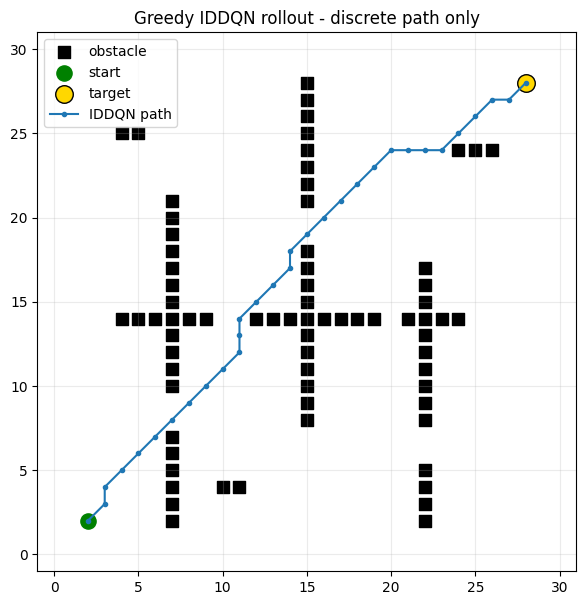

In [27]:
# Same greedy rollout without Bezier smoothing.
# Use this to inspect the exact discrete actions learned by IDDQN.
plot_environment(env, path=path, smoothed=None, title="Greedy IDDQN rollout - discrete path only");

In [28]:
def path_length(path):
    pts = np.array(path, dtype=np.float32)
    if len(pts) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1)))


def path_corners(path):
    pts = np.array(path, dtype=np.float32)
    if len(pts) < 3:
        return 0
    dirs = np.diff(pts, axis=0)
    dirs = np.array([tuple(d) for d in dirs])
    return int(np.sum(np.any(dirs[1:] != dirs[:-1], axis=1)))


def min_distance_to_obstacles(path, obstacles):
    pts = np.array(path, dtype=np.float32)
    obs = np.array(obstacles, dtype=np.float32)
    if len(pts) == 0 or len(obs) == 0:
        return float("inf")
    return float(np.min(np.linalg.norm(pts[:, None, :] - obs[None, :, :], axis=2)))


metrics = {
    "path_length": path_length(path),
    "corners": path_corners(path),
    "min_obstacle_distance": min_distance_to_obstacles(path, env.obstacles),
    "reached_target": info.get("reached", False),
}
metrics

{'path_length': 39.11270523071289,
 'corners': 10,
 'min_obstacle_distance': 1.0,
 'reached_target': True}

In [29]:
# Save/load checkpoints for later novelty experiments.
MODEL_PATH = "iddqn_paper_grid_model.pth"
torch.save({
    "model_state_dict": agent.current_net.state_dict(),
    "config": cfg.__dict__,
    "history": history,
}, MODEL_PATH)
MODEL_PATH

'iddqn_paper_grid_model.pth'